# Bài toán:

> **Phân cụm dữ liệu bằng giải thuật K-means (unsupervised learning)**

Mục tiêu

- Xây dựng mô hình Kmeans sử dụng thư viện sklearn.
- Áp dụng hai mô hình để giải bài toán thực tế (nén ảnh).
- Nắm được cách tinh chỉnh tham số và đánh giá chất lượng mô hình

Dữ liệu

- Bài toán mô phỏng Kmeans: Sử dụng hàm sinh dữ liệu tự động của sklearn (sinh ra các điểm ngẫu nhiên theo phân phối Gauss). Mỗi dữ liệu là một điểm trên mặt phẳng Oxy
- Bài toán nén ảnh: Ảnh bird_small.png (Hình ảnh về một chú chim)

Mô hình hóa bài toán: bài toán phân cụm.

- Đâu vào: $N$ vector $D$ chiều, tương ứng $N$ điểm dữ liệu với $D$ thuộc tính trong không gian. Số cụm khởi tạo.
- Đầu ra: Các tâm cụm và chỉ số cụm của mỗi điểm dữ liệu đã cho ban đầu.


# Các bước làm


## Các thư viện sử dụng


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs


## Bài toán 1: Mô phỏng Kmeans với dữ liệu tự sinh (không gian Oxy)


### Chuẩn bị dữ liệu

- Sinh dữ liệu ngẫu nhiên n_samples = 100 tương đương 100 điểm
  - random_state: biến cố định hàm random - để các điểm sinh ngẫu nhiên
- Mỗi điểm dữ liệu có 2 chiều


In [2]:
n_samples = 100
random_state = 170
center_points = [
    [1, 1],
    [-1, -1],
    [1, -1],
]  # sinh ngẫu nhiên các điểm xung quanh vị trí tâm cố định
# center_points = 3                           # tâm cụm được chọn ngẫu nhiên

X, y = make_blobs(
    n_samples=n_samples,
    random_state=random_state,
    centers=center_points,
    cluster_std=0.6,
)
print("Số chiều dữ liệu: ", X.shape, y.shape)
print("5 điểm dữ liệu đầu tiên: \n", X[:5])

Số chiều dữ liệu:  (100, 2) (100,)
5 điểm dữ liệu đầu tiên: 
 [[ 1.26241305  0.94872541]
 [-0.39743873 -1.18567406]
 [ 1.35081331  0.48041993]
 [ 1.21219555  0.98929291]
 [-0.75344338 -1.09784774]]


In [3]:
set(y)

{np.int64(0), np.int64(1), np.int64(2)}

**Vẽ các điểm ảnh sử dụng matlib plot**


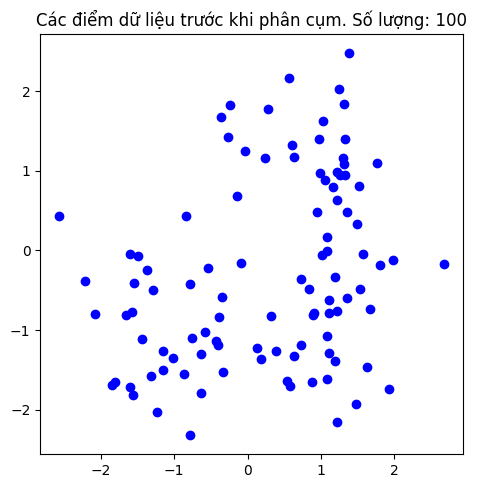

In [4]:
plt.figure(figsize=(12, 12))
plt.subplot(221)
plt.scatter(
    X[:, 0], X[:, 1], c="blue"
)  # c là tham số chọn màu sắc, có thể truyền vào string hoặc số id 1,2,3 ...
plt.title("Các điểm dữ liệu trước khi phân cụm. Số lượng: {}".format(n_samples))
plt.show()

### Dựng giải thuật K-means và huấn luyện

- Sử dụng thư viện sklearn để xây dựng giải thuật K-means, xem chi tiết tại [tài liệu hướng dẫn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)


In [5]:
k_cluster = 3
k_mean_model = KMeans(n_clusters=k_cluster, random_state=random_state)
k_mean_model.fit(X)

centers = np.array(
    k_mean_model.cluster_centers_
)  # cluster_centers_: là thuộc tính lưu trữ các
# tâm cụm sau khi training
print("Tâm cụm sau khi training ({} tâm): \n".format(k_cluster), centers)


Tâm cụm sau khi training (3 tâm): 
 [[ 1.11177838 -0.94555162]
 [ 0.88823619  1.19442485]
 [-1.13949326 -0.97100768]]


### Đánh giá mô hình

- Kiểm tra các điểm dữ liệu thuộc vào cụm nào
- Vẽ biểu đồ hiển thị, trong đó các điểm thuộc các cụm khác nhau sẽ có các màu khác nhau


Kết quả dự đoán cho 5 mẫu dữ liệu đầu tiên trong tập data: 

[1 2 1 1 2]


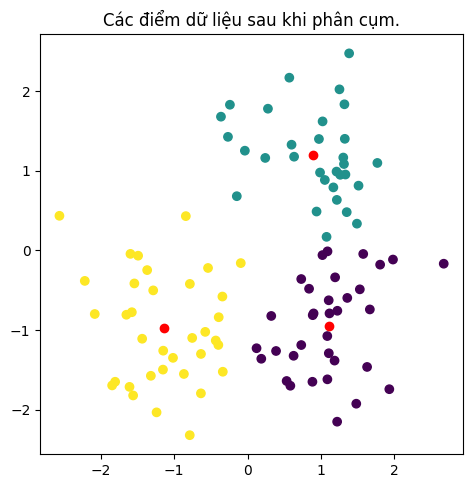

In [6]:
y_pred = k_mean_model.predict(X)
print("Kết quả dự đoán cho 5 mẫu dữ liệu đầu tiên trong tập data: \n")
print(y_pred[:5])

plt.figure(figsize=(12, 12))
plt.subplot(222)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.scatter(centers[:, 0], centers[:, 1], c="red")
plt.title("Các điểm dữ liệu sau khi phân cụm.")
plt.show()

### Bài tập 1

Yêu cầu: Thử nghiệm trường hợp dữ liệu sinh ra chỉ có 2 cụm nhưng huấn luyện K-means với các tham số k = 3,4,5 cụm


- Tự viết code sinh dữ liệu tương tự bên trên
- Xây dựng mô hình 3,4,5 cụm

Gợi ý: thay đổi tham số số cụm khi dựng giải thuật K-means

Kết quả phải ra được hình ảnh thể hiện đúng số tâm cụm và phân bố cụm.


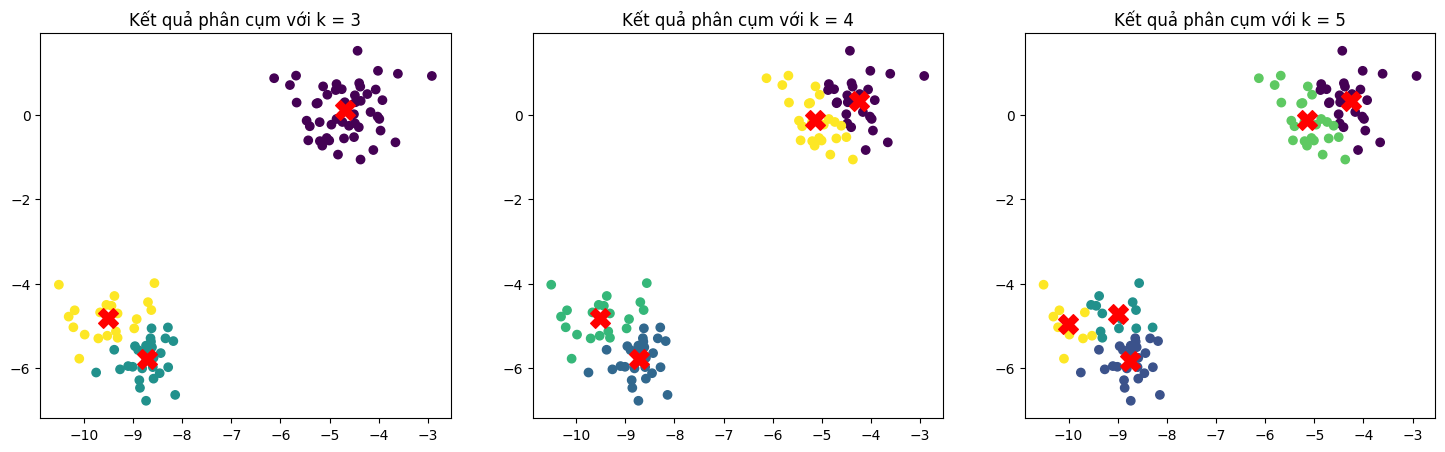

In [7]:
# Sinh dữ liệu tương ứng với giả thiết có 2 cụm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Tạo dữ liệu ngẫu nhiên nhưng chỉ có 2 tâm (2 clusters)
n_samples_ex1 = 100
random_state_ex1 = 170
X_ex1, y_ex1 = make_blobs(
    n_samples=n_samples_ex1,
    random_state=random_state_ex1,
    centers=2,  # Chỉ có 2 cụm tự nhiên
    cluster_std=0.6,
)

# Xây dựng mô hình với 3, 4, 5 cụm và trực quan hóa kết quả phân cụm tương ứng.
k_values = [3, 4, 5]
plt.figure(figsize=(18, 5))

for i, k in enumerate(k_values):
    kmeans_ex1 = KMeans(n_clusters=k, random_state=random_state_ex1)
    kmeans_ex1.fit(X_ex1)
    y_pred_ex1 = kmeans_ex1.predict(X_ex1)
    centers_ex1 = kmeans_ex1.cluster_centers_

    plt.subplot(1, 3, i + 1)
    plt.scatter(X_ex1[:, 0], X_ex1[:, 1], c=y_pred_ex1)
    plt.scatter(
        centers_ex1[:, 0],
        centers_ex1[:, 1],
        c="red",
        marker="X",
        s=200,
        label="Mức độ nén (Centers)",
    )
    plt.title(f"Kết quả phân cụm với k = {k}")

plt.show()

## Bài toán 2: Ứng dụng Kmeans cho nén ảnh

- Đặt vấn đề:
  - Muốn xây dựng 1 hệ thống nén dữ liệu hình ảnh
  - Có thể tuỳ chỉnh được độ sắc nét, giảm kích thước bộ nhớ, nhưng không làm sai lệch quá nhiều dưới mắt nhìn.
- Giải pháp
  - Sử dụng giải thuật K-means, tự động phân cụm các điểm ảnh, giới hạn số lượng màu để giảm kích thước ảnh
  - Mỗi điểm ảnh sẽ được quy về 1 cụm nào đó, mang giá trị màu bằng màu của tâm cụm.


### Thư viện sử dụng - hỗ trợ hình ảnh


In [8]:
from skimage import io
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as image
from IPython.display import Image, display  # Hiển thị ảnh

### Đọc dữ liệu hình ảnh

- Mỗi điểm ảnh là 1 mẫu quan sát
- Phân cụm tập dữ liệu (tập các điểm ảnh) về k nhãn


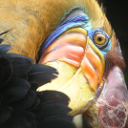

In [9]:
path_img = "bird_small.png"
Image(path_img, width=250, unconfined=True)

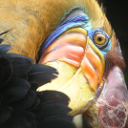

In [10]:
path_img = "bird_small.png"

display(Image(path_img, width=250, unconfined=True))

In [11]:
img = io.imread(path_img)
img

array([[[219, 180, 103],
        [230, 185, 116],
        [226, 186, 110],
        ...,
        [ 14,  15,  13],
        [ 13,  15,  12],
        [ 12,  14,  12]],

       [[230, 193, 119],
        [224, 192, 120],
        [226, 192, 124],
        ...,
        [ 16,  16,  13],
        [ 14,  15,  10],
        [ 11,  14,   9]],

       [[228, 191, 123],
        [228, 191, 121],
        [220, 185, 118],
        ...,
        [ 14,  16,  13],
        [ 13,  13,  11],
        [ 11,  15,  10]],

       ...,

       [[ 15,  18,  16],
        [ 18,  21,  18],
        [ 18,  19,  16],
        ...,
        [ 81,  45,  45],
        [ 70,  43,  35],
        [ 72,  51,  43]],

       [[ 16,  17,  17],
        [ 17,  18,  19],
        [ 20,  19,  20],
        ...,
        [ 80,  38,  40],
        [ 68,  39,  40],
        [ 59,  43,  42]],

       [[ 15,  19,  19],
        [ 20,  20,  18],
        [ 18,  19,  17],
        ...,
        [ 65,  43,  39],
        [ 58,  37,  38],
        [ 52,  39,  34]]

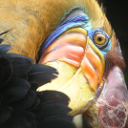

Dữ liệu ảnh trước khi reshape: (128, 128, 3)
Số chiều của dữ liệu hình ảnh:  (16384, 3)
Tổng số điểm ảnh là:  16384
Mỗi điểm ảnh có số chiều =  3


In [12]:
path_img = "bird_small.png"

display(Image(path_img, width=250, unconfined=True))

img = io.imread(path_img)
print("Dữ liệu ảnh trước khi reshape:", img.shape)

img_shape = img.shape  # 128x128x3
data_img = (img / 255.0).reshape(
    -1, img.shape[2]
)  # chuyển ma trận 128x128x3 về mảng 2 chiều, giữ lại chiều .shape[2]

print("Số chiều của dữ liệu hình ảnh: ", data_img.shape)
print("Tổng số điểm ảnh là: ", data_img.shape[0])
print("Mỗi điểm ảnh có số chiều = ", data_img.shape[1])

In [13]:
img.shape

(128, 128, 3)

In [14]:
data_img.shape

(16384, 3)

In [15]:
a = np.array(
    [[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]], [[13, 14, 15], [16, 17, 18]]]
)
a.shape

(3, 2, 3)

In [16]:
a.reshape(-1, 3)

array([[ 1,  2,  3],
       [ 4,  5,  6],
       [ 7,  8,  9],
       [10, 11, 12],
       [13, 14, 15],
       [16, 17, 18]])

### Xây dựng mô hình kmean để nén ảnh

- Số lượng cụm chính là số lượng màu ta giữ lại
- Số lượng cụm càng nhỏ thì kích thước ảnh cho ra càng nhỏ


In [17]:
n_color = 10
k_mean_model = KMeans(n_clusters=n_color)

**Huấn luyện mô hình**


In [18]:
k_mean_model.fit(data_img)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [19]:
# Hiển thị một số thông tin đã học của mô hình
print("Số chiều của tâm cụm: ", k_mean_model.cluster_centers_.shape)
print(k_mean_model.cluster_centers_)
print(k_mean_model.labels_[0:20])

Số chiều của tâm cụm:  (10, 3)
[[0.2174648  0.20402141 0.1950429 ]
 [0.84576148 0.70480646 0.46569596]
 [0.61280547 0.44765743 0.21343809]
 [0.97075288 0.93983535 0.80410118]
 [0.60958459 0.53227631 0.47916601]
 [0.09299986 0.10029859 0.09032028]
 [0.52973923 0.63364882 0.78017651]
 [0.81497483 0.58839881 0.2924796 ]
 [0.90789845 0.8010039  0.66168589]
 [0.4077349  0.34004631 0.30396184]]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


### Hiển thị ảnh mới sau khi nén


In [20]:
# k_mean_model.labels_: chứa nhãn của tất cả các điểm ảnh
# k_mean_model.cluster_centers_: chứa các tâm cụm.
# new_arr = arr1[index]
img128 = k_mean_model.cluster_centers_[k_mean_model.labels_]

print(img128.shape)

# chuẩn hoá lại kích thước ảnh theo chiều dài, rộng ban đầu
img128 = np.reshape(img128, img_shape)
print(img128.shape)
image.imsave("img128.png", img128)

(16384, 3)
(128, 128, 3)


In [21]:
# hiển thị kích thước hình ảnh trước và sau khi nén
import os

print("Size of compressed image: " + str(os.path.getsize("img128.png")) + " KB")
print("Size of original image: " + str(os.path.getsize("bird_small.png")) + " KB")

Size of compressed image: 7271 KB
Size of original image: 33031 KB


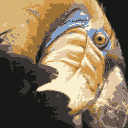

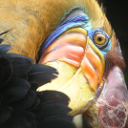

In [22]:
from IPython.display import Image, display

# Save image
display(Image("img128.png", width=250, unconfined=True))
display(Image(path_img, width=250, unconfined=True))

### Bài tập 2

Yêu cầu: Nén ảnh trên thành ảnh có số màu < 5 và kiểm tra

Gợi ý: thay đổi tham số "số cụm" khi xây dựng K-means


Size of image compressed (k=4): 3429 Bytes
Size of original image: 33031 Bytes


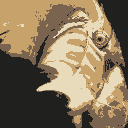

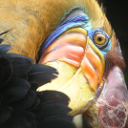

In [23]:
# Chọn số lượng màu k = 4 (< 5)
n_color_2 = 4
k_mean_model_2 = KMeans(n_clusters=n_color_2, random_state=42)

# Huấn luyện mô hình
k_mean_model_2.fit(data_img)

# Tạo lại ảnh
img128_k4 = k_mean_model_2.cluster_centers_[k_mean_model_2.labels_]
img128_k4 = np.reshape(img128_k4, img_shape)

# Lưu ảnh mới
image.imsave("img128_k4.png", img128_k4)

# Hiển thị và so sánh dung lượng ảnh
import os

print(
    "Size of image compressed (k=4): "
    + str(os.path.getsize("img128_k4.png"))
    + " Bytes"
)
print("Size of original image: " + str(os.path.getsize("bird_small.png")) + " Bytes")

# Trực quan hóa
display(Image("img128_k4.png", width=250, unconfined=True))
display(Image(path_img, width=250, unconfined=True))

## Bài tập bổ sung


Làm sao để biết số cụm bằng bao nhiêu là phù hợp với dữ liệu ?


Sử dụng tiêu chuẩn inertia để đánh giá: inertia được tính bằng tổng bình phương khoảng cách của các mẫu đến trung tâm cụm gần nhất của chúng


Một mô hình tốt là mô hình có chỉ số inertia nhỏ và số lượng cụm bé. Vấn đề: số cụm càng lớn thì inertia càng nhỏ. Chọn số cụm hợp lý bằng cách: chọn điểm mà độ giảm inertia bắt đầu chậm lại.


In [24]:
# Ví dụ tính inertia cho mô hình đầu tiên
k_mean_model.inertia_

190.8995117038839

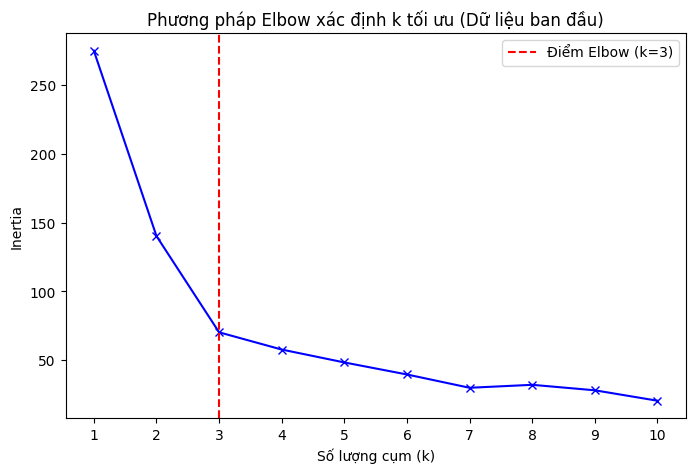

In [25]:
### Bài tập ###
# Viết code tính inertia_ cho mô hình của dữ liệu điểm ban đầu, số lượng cụm từ 1 đến 10
inertias = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km = km.fit(X)
    inertias.append(km.inertia_)

# Vẽ đồ thị để quan sát sự giảm của inertia và chọn số lượng cụm phù hợp
plt.figure(figsize=(8, 5))
plt.plot(K, inertias, "bx-")
plt.xlabel("Số lượng cụm (k)")
plt.ylabel("Inertia")
plt.title("Phương pháp Elbow xác định k tối ưu (Dữ liệu ban đầu)")
plt.xticks(K)
plt.axvline(x=3, color="r", linestyle="--", label="Điểm Elbow (k=3)")
plt.legend()
plt.show()

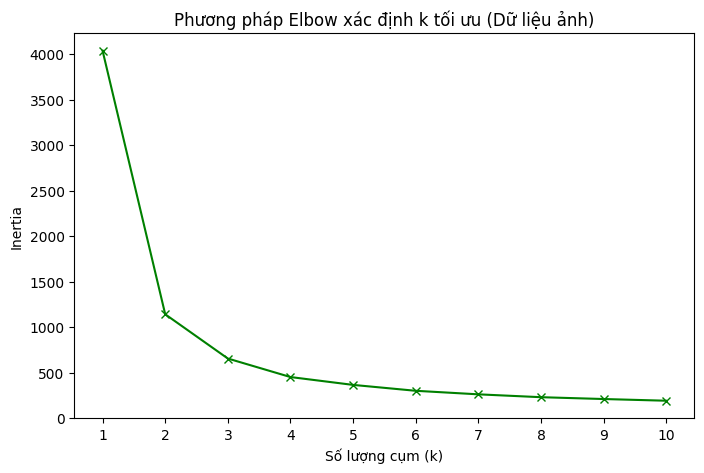

In [26]:
### Bài tập ###
# Viết code tính inertia_ cho mô hình của dữ liệu hình ảnh, số lượng cụm từ 1 đến 10
inertias_img = []
K_img = range(1, 11)
for k in K_img:
    km_img = KMeans(n_clusters=k, random_state=42)
    km_img = km_img.fit(data_img)
    inertias_img.append(km_img.inertia_)

# Vẽ đồ thị để quan sát sự giảm của inertia và chọn số lượng cụm phù hợp
plt.figure(figsize=(8, 5))
plt.plot(K_img, inertias_img, "gx-")
plt.xlabel("Số lượng cụm (k)")
plt.ylabel("Inertia")
plt.title("Phương pháp Elbow xác định k tối ưu (Dữ liệu ảnh)")
plt.xticks(K_img)
plt.show()